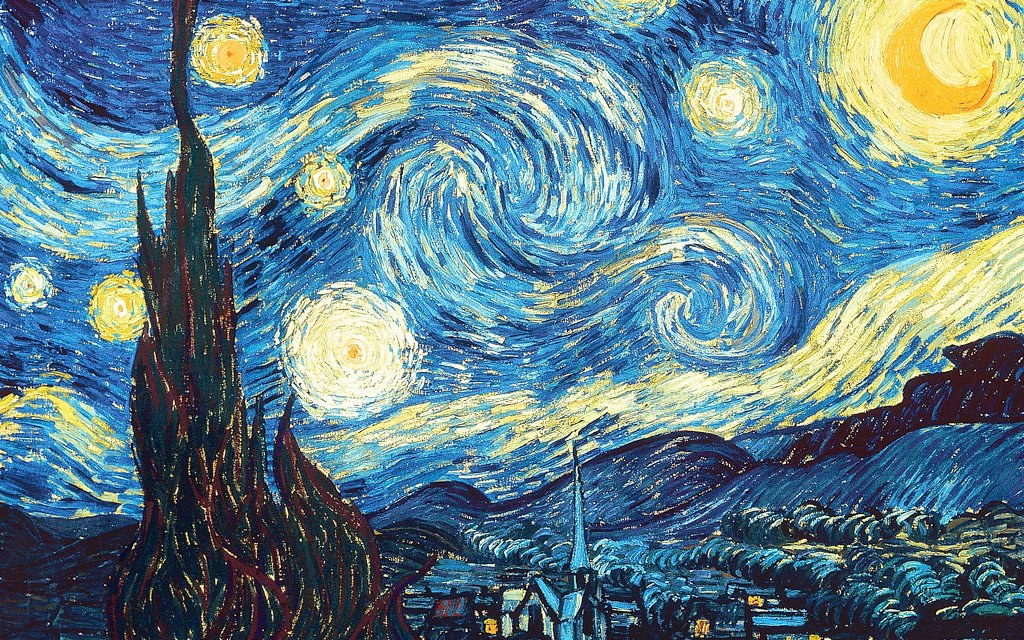

In [1]:
from PIL import Image

image_path = "images/starry_night.jpg"
image = Image.open(image_path)
image

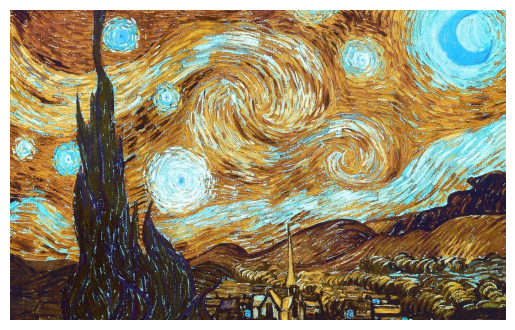

In [2]:
import cv2
import matplotlib.pyplot as plt

image_cv = cv2.imread(image_path)

plt.imshow(image_cv)
plt.axis("off")
plt.show()

In [3]:
import numpy as np

print(np.array(image)[0][0]) # RGB
print(image_cv[0][0]) # BGR

[  6  22 109]
[109  22   6]


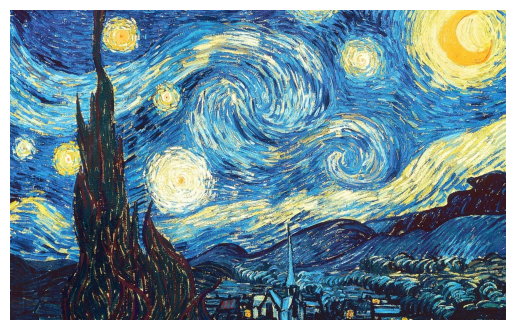

In [5]:
image_cv2 = cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)

plt.imshow(image_cv2)
plt.axis("off")
plt.show()

## 2. 이미지 정보 파악하기

In [11]:
print(type(image_cv2))
print(image_cv2.shape)
print(image_cv2.ndim)
print(image_cv2.dtype)
print(image_cv2.size)

<class 'numpy.ndarray'>
(640, 1024, 3)
3
uint8
1966080


## 3. 이미지 변환하기

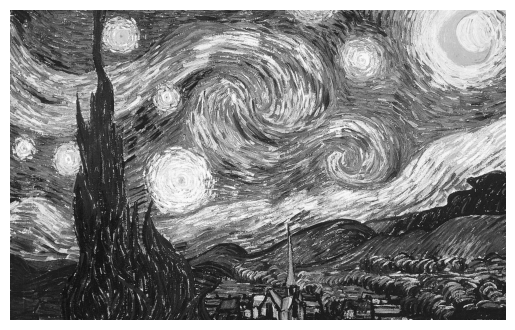

In [12]:
image_cv3 = cv2.cvtColor(image_cv, cv2.COLOR_BGR2GRAY)

plt.imshow(image_cv3, cmap='gray')
plt.axis("off")
plt.show()

## 4. 이미지 저장하기

In [13]:
save_path = "images/starry_night_gray.jpg"

cv2.imwrite(save_path, image_cv3)

True

## 5. 이미지 그리기

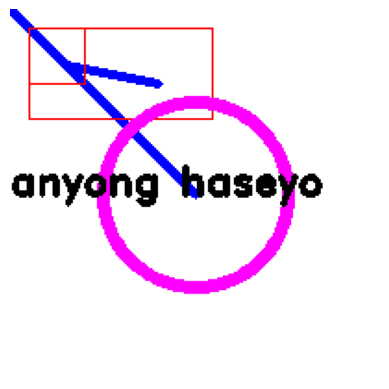

In [30]:
import cv2
import matplotlib.pyplot as plt

#하얀 도화지 만들기 RGB채널로 (255, 255, 255)
image = np.zeros((200, 200, 3), dtype=np.uint8) +255

#선 그리기 (이미지 - 시작점)
cv2.line(image, (0,0), (100,100), (0,0,255), 3, lineType=cv2.LINE_8)
cv2.line(image, (30,30), (80,40), (0,0,255), 3, lineType=cv2.FILLED)

#사각형 그리기 (이미지 왼위쪽 점, 오른쪽 아래 점, 색상, 두께, 그외 옵션)
cv2.rectangle(image, (10, 10), (40, 40), (255, 0, 0), 1)
#사각형 그리기 (이미지, (시작점위치, 너비, 높이), 색상, 두께, 그외 옵션)
cv2.rectangle(image, (10, 10, 100, 50), (255, 0, 0), 1)

#원그리기 (이미지 - 중심점 - 반지름, 색상, 두께, 그외 옵션)
cv2.circle(image, (100, 100), 50, (255, 0, 255), 5, lineType=cv2.FILLED)

#텍스트 넣기(이미지 - 텍스트 - 위치 - 폰트 - 크기 - 색상 - 두께)
text = "anyong haseyo"
cv2.putText(image, text, (0,100), cv2.FONT_HERSHEY_DUPLEX, 0.7, (0,0,0), 2)

plt.imshow(image)
plt.axis("off")
plt.show()

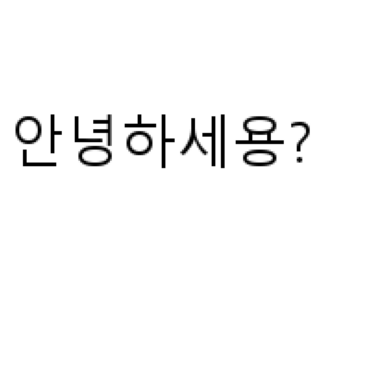

In [34]:
import cv2
import matplotlib.pyplot as plt
from PIL import ImageFont, ImageDraw, Image

#하얀 도화지 만들기 RGB채널로 (255, 255, 255)
image = np.zeros((200, 200, 3), dtype=np.uint8) +255

#한글 텍스트 넣기
font_path = "C:/Windows/Fonts/malgun.ttf"
#폰트와 크기 설정
font = ImageFont.truetype(font_path, 30)

text = "안녕하세용?"

#넘파이 배열을 이미지로 바꿈
image = Image.fromarray(image)
#이미지에 그림그릴 준비
draw = ImageDraw.Draw(image)
#이미제에 텍스트 넣기
draw.text((0,50), text, font=font, fill=(0,0,0))
#이미지를 넘파이 배열로 바꿈
text_image = np.array(image)

plt.imshow(image)
plt.axis("off")
plt.show()

## 6. 마스크 씌우기

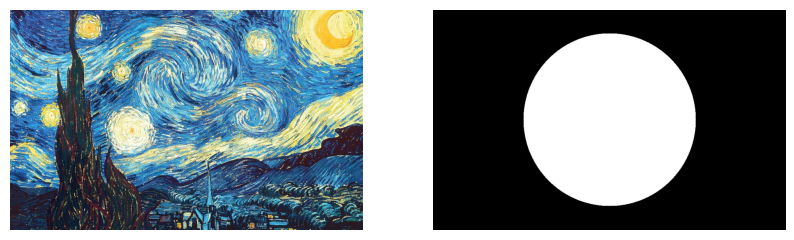

In [35]:
# starry_night.jpg
# circle.jpg

import cv2
import matplotlib.pyplot as plt

image_path1 = "images/starry_night.jpg"
image_path2 = "images/circle.jpg"

image1 = cv2.imread(image_path1)
image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)

image2 = cv2.imread(image_path2)
image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(image1)
ax[0].axis("off")
ax[1].imshow(image2)
ax[1].axis("off")
plt.show()

(640, 1024, 3) (640, 1024) (640, 1024, 3)


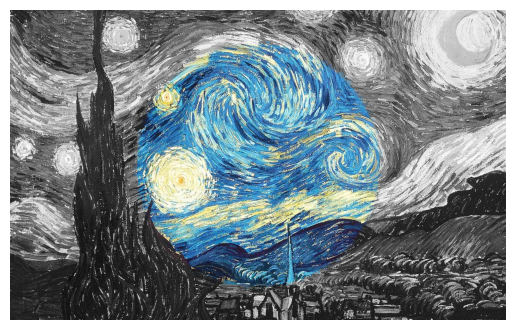

In [39]:
import numpy as np
image_path = "images/starry_night.jpg"
mask_path = "images/circle.jpg"

image = cv2.imread(image_path)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

dst = np.zeros(image.shape, dtype=image.dtype)

background = cv2.imread("images/starry_night_gray.jpg")

print(image.shape, mask.shape, dst.shape)

#이미지 합성하기
cv2.copyTo(image, mask, background)

plt.imshow(background)
plt.axis("off")
plt.show()


# 7. 이미지 처리

### 색상 추출

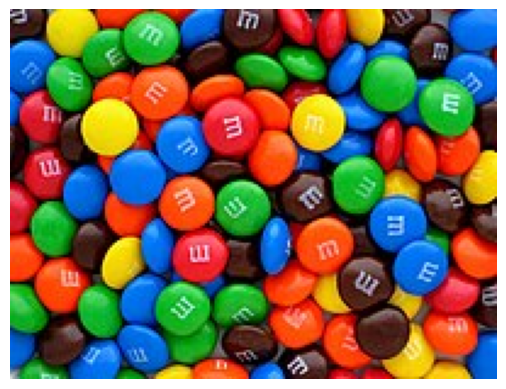

In [41]:
# 초콜릿 이미지 
image = cv2.imread("images/chocolate.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")
plt.show()

(152, 200) (152, 200) (152, 200)


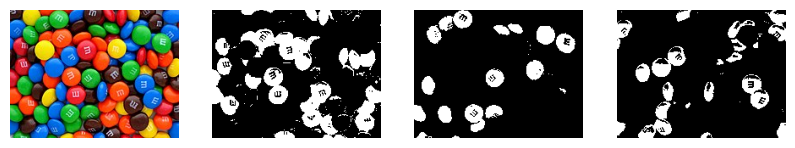

In [52]:
# 색상별로 마스크를 추출

#어떤 범위에 있는 색상만 추출하는 마스크 추출 코드(이미지 - 색상 하한선, 색상 상한선)
#빨간색 추출
mask_r = cv2.inRange(image, (128, 0, 0), (255, 128, 128))
#초록색 추출
mask_g = cv2.inRange(image, (0, 128, 0), (128, 255, 128))
#파란색 추출
mask_b = cv2.inRange(image, (0, 0, 128), (128, 128, 255))

print(mask_r.shape, mask_g.shape, mask_b.shape)

fig, ax = plt.subplots(1, 4, figsize=(10,4))
ax[0].imshow(image)
ax[0].axis('off')
ax[1].imshow(mask_r, cmap='gray')
ax[1].axis('off')
ax[2].imshow(mask_g, cmap='gray')
ax[2].axis('off')
ax[3].imshow(mask_b, cmap='gray')
ax[3].axis('off')
plt.show()

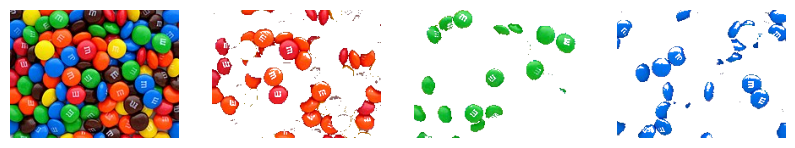

In [58]:
white_dst = np.zeros(image.shape, dtype=np.uint8) + 255
image_red = cv2.copyTo(image, mask_r, white_dst)

white_dst = np.zeros(image.shape, dtype=np.uint8) + 255
image_green = cv2.copyTo(image, mask_g, white_dst)

white_dst = np.zeros(image.shape, dtype=np.uint8) + 255
image_blue = cv2.copyTo(image, mask_b, white_dst)

fig, ax = plt.subplots(1, 4, figsize=(10,4))

ax[0].imshow(image)
ax[0].axis('off')
ax[1].imshow(image_red, cmap='gray')
ax[1].axis('off')
ax[2].imshow(image_green, cmap='gray')
ax[2].axis('off')
ax[3].imshow(image_blue, cmap='gray')
ax[3].axis("off")

plt.show()

### 가우시안 블러

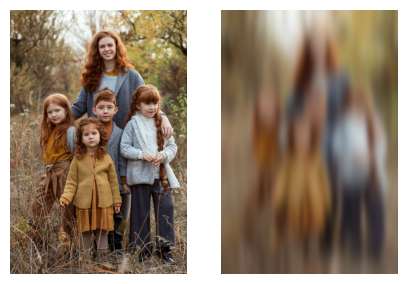

In [ ]:
#family.jpg
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("images/family.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

sigma=5
image_blur = cv2.GaussianBlur(image, (0,0), sigmaX=10, sigmaY=50)

fig, ax = plt.subplots(1, 2, figsize=(5,4))
ax[0].imshow(image)
ax[0].axis("off")
ax[1].imshow(image_blur)
ax[1].axis("off")

plt.show()

### 밝기/대비 조절

In [69]:
#밝기조절: 이미지 전체의 색을 밝게 조정하는 것
#대비 좆절: 밝은 부분과 어두운 부분의 차이를 강조하거나 줄이는 것

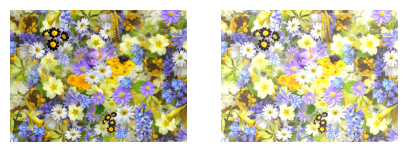

In [83]:
# flowers.jpg

import cv2
import matplotlib.pyplot as plt

image = cv2.imread("images/flowers.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

image_bright = cv2.convertScaleAbs(image, alpha=1, beta=50)

fig, ax = plt.subplots(1, 2, figsize=(5,4))
ax[0].imshow(image)
ax[0].axis("off")
ax[1].imshow(image_bright)
ax[1].axis("off")

plt.show()

### 대비 조절

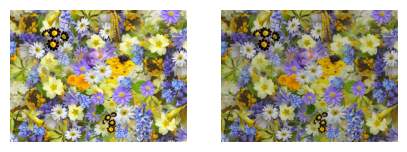

In [93]:
# flowers.jpg

import cv2
import matplotlib.pyplot as plt

image = cv2.imread("images/flowers.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

#alpha: 대비, beta:밝기
image_contrast = cv2.convertScaleAbs(image, alpha=0.8, beta=1)

fig, ax = plt.subplots(1, 2, figsize=(5,4))
ax[0].imshow(image)
ax[0].axis("off")
ax[1].imshow(image_contrast)
ax[1].axis("off")

plt.show()

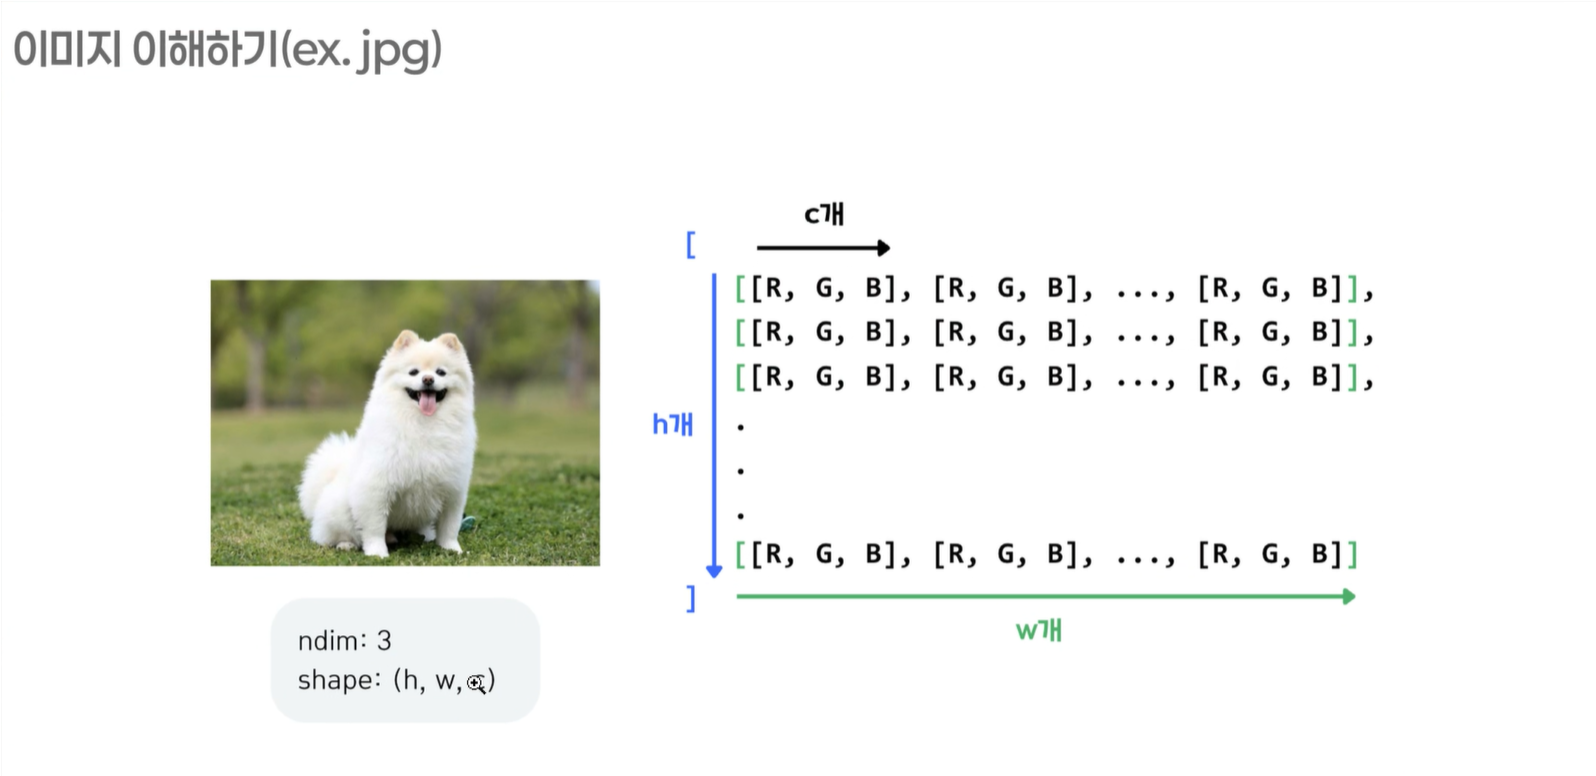

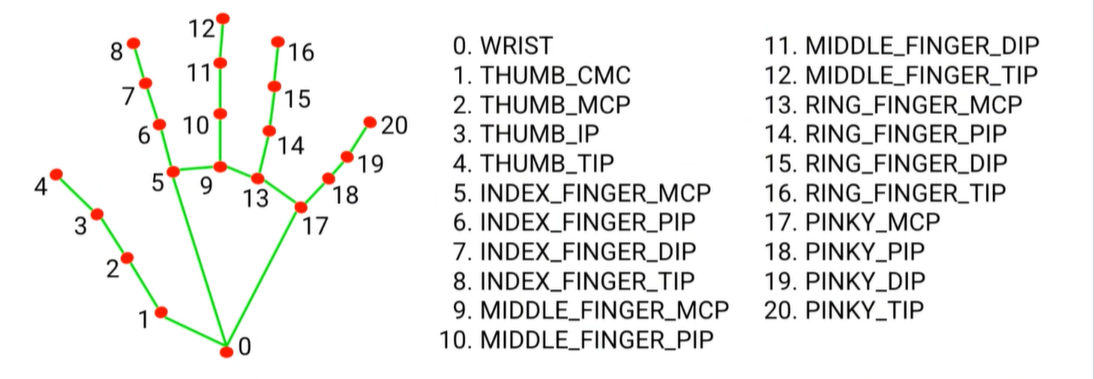